In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans


In [3]:
# TASK 1: COLLECT CUSTOMER TRANSACTION DATA
df= pd.read_csv(r"C:\Users\Brithi S\Downloads\Customer_segmentation.csv")

In [4]:
print("Dataset Loaded Successfully")
print("\nFirst 5 Records:")
print(df.head())


Dataset Loaded Successfully

First 5 Records:
   CustomerID  Age  Gender  AnnualIncome  SpendingScore  Transactions
0           1   22  Female         25000             81            15
1           2   35    Male         45000             45            10
2           3   28  Female         38000             76            18
3           4   42    Male         62000             35             8
4           5   31  Female         54000             67            14


In [5]:
# TASK 2: CLEAN AND PREPROCESS DATASET
print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     30 non-null     int64
 1   Age            30 non-null     int64
 2   Gender         30 non-null     str  
 3   AnnualIncome   30 non-null     int64
 4   SpendingScore  30 non-null     int64
 5   Transactions   30 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.5 KB
None

Missing Values
CustomerID       0
Age              0
Gender           0
AnnualIncome     0
SpendingScore    0
Transactions     0
dtype: int64


In [6]:
# Remove duplicates
df = df.drop_duplicates()

In [7]:
print("\nNumber of Records After Removing Duplicates:", len(df))



Number of Records After Removing Duplicates: 30


In [8]:
# Encode Gender Column
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

In [9]:
# Normalize numerical columns
scaler = MinMaxScaler()
df[['AnnualIncome', 'SpendingScore', 'Transactions']] = scaler.fit_transform(
    df[['AnnualIncome', 'SpendingScore', 'Transactions']]
)

print("\nPreprocessed Data")
print(df.head())



Preprocessed Data
   CustomerID  Age  Gender  AnnualIncome  SpendingScore  Transactions
0           1   22       0      0.000000       0.835821      0.523810
1           2   35       1      0.333333       0.298507      0.285714
2           3   28       0      0.216667       0.761194      0.666667
3           4   42       1      0.616667       0.149254      0.190476
4           5   31       0      0.483333       0.626866      0.476190


In [10]:
# TASK 3: APPLY CUSTOMER SEGMENTATION
X = df[['AnnualIncome', 'SpendingScore']]

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [11]:
df['Cluster'] = kmeans.fit_predict(X)

print("\nCluster Assigned Successfully")


Cluster Assigned Successfully


In [12]:
# TASK 4: ANALYZE CUSTOMER GROUPS
print("\nCustomer Groups Analysis")

cluster_analysis = df.groupby('Cluster').agg({
    'AnnualIncome': 'mean',
    'SpendingScore': 'mean',
    'Transactions': 'mean',
    'CustomerID': 'count'
})


Customer Groups Analysis


In [13]:
cluster_analysis.rename(
    columns={'CustomerID': 'TotalCustomers'},
    inplace=True
)

print(cluster_analysis)


         AnnualIncome  SpendingScore  Transactions  TotalCustomers
Cluster                                                           
0            0.581481       0.285240      0.291005               9
1            0.121667       0.885075      0.761905              10
2            0.423333       0.602985      0.466667               5
3            0.844444       0.077114      0.079365               6


In [14]:
# TASK 5: GENERATE BUSINESS INSIGHTS
print("\nBUSINESS INSIGHTS")

for cluster in sorted(df['Cluster'].unique()):

    customers = df[df['Cluster'] == cluster]

    avg_income = customers['AnnualIncome'].mean()
    avg_spending = customers['SpendingScore'].mean()

    print(f"\nCluster {cluster}")

    if avg_income > 0.6 and avg_spending > 0.6:
        print("Premium Customers")
        print("Recommendation: VIP offers and loyalty rewards")

    elif avg_income > 0.6 and avg_spending <= 0.6:
        print("Potential Customers")
        print("Recommendation: Personalized discounts")

    elif avg_income <= 0.6 and avg_spending > 0.6:
        print("Regular Customers")
        print("Recommendation: Product recommendations")

    else:
        print("Budget Customers")
        print("Recommendation: Affordable product promotions")




BUSINESS INSIGHTS

Cluster 0
Budget Customers
Recommendation: Affordable product promotions

Cluster 1
Regular Customers
Recommendation: Product recommendations

Cluster 2
Regular Customers
Recommendation: Product recommendations

Cluster 3
Potential Customers
Recommendation: Personalized discounts


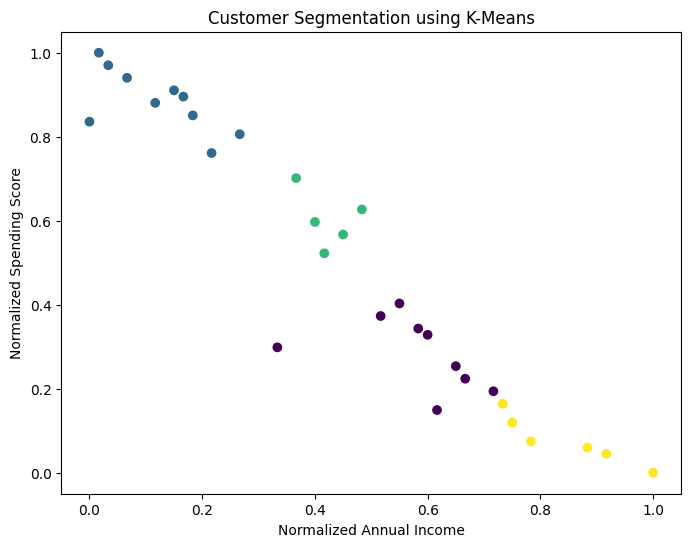

In [15]:
# VISUALIZATION
plt.figure(figsize=(8,6))

plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore'],
    c=df['Cluster']
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Normalized Annual Income")
plt.ylabel("Normalized Spending Score")

plt.show()